In [ ]:
Setup, Load Image

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from skimage import io, filters, measure, color
from skimage.filters import rank
from scipy import ndimage

IMAGE_PATH = "data/Ex 3 day 1814/1_image_BGR- Red.tif"

def load_red_channel(path):
    image = io.imread(path)

    if image.ndim == 3:
        # Konvertierung zu 8-Bit, falls die Eingabe 16-Bit ist (häufig bei TIF)
        return (image[:, :, 0]).astype(np.uint8)
    elif image.ndim == 2:
         return image.astype(np.uint8)
    else:
        raise ValueError("Image must be 2D (grayscale) or 3D (color).")

Pre-Processing (Local Normalization)

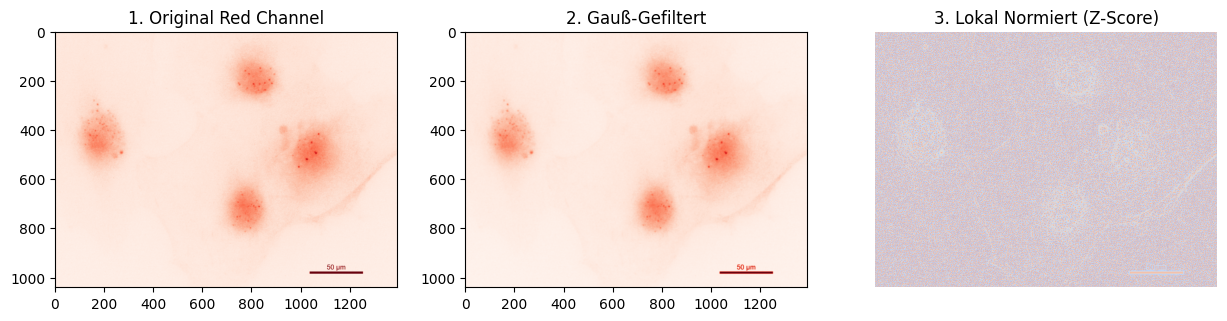

In [5]:
WINDOW_SIZE = 5
EPSILON = 1e-6

def preprocess_and_normalize(img_red_raw, window_size, epsilon):

    # 1. Gauß-Filter (Rauschunterdrückung)
    # Sigma=1 ist ein guter Wert für leichte Glättung
    img_red_smoothed = filters.gaussian(img_red_raw, sigma=1)

    # 2. Lokale Statistik (Mean & Std Dev)
    # Erstellung eines flachen strukturierten Elements (Rechteck)
    selem = np.ones((window_size, window_size))

    # Berechnung des lokalen Mittelwerts und der Standardabweichung
    # Wir verwenden scipy.ndimage, da es oft schneller ist als filters.rank
    local_mean = ndimage.uniform_filter(img_red_smoothed, size=window_size)
    local_std = np.sqrt(ndimage.uniform_filter(img_red_smoothed**2, size=window_size) - local_mean**2)

    # 3. Z-Score Normierung: (Pixel - lokaler Mittelwert) / (lokale Standardabweichung + Epsilon)
    img_red_norm = (img_red_smoothed - local_mean) / (local_std + epsilon)

    return img_red_norm, img_red_smoothed

# --- Ausführung des Pre-Processings ---
try:
    img_red_raw = load_red_channel(IMAGE_PATH)
    img_red_norm, img_red_smoothed = preprocess_and_normalize(img_red_raw, WINDOW_SIZE, EPSILON)

    # Visualisierung der Normierung (zur Kontrolle)
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(img_red_raw, cmap='Reds'); axs[0].set_title("1. Original Red Channel")
    axs[1].imshow(img_red_smoothed, cmap='Reds'); axs[1].set_title("2. Gauß-Gefiltert")
    axs[2].imshow(img_red_norm, cmap='coolwarm'); axs[2].set_title("3. Lokal Normiert (Z-Score)")
    axs[2].axis('off') # Hier muss die Achse aus, sonst wird der coolwarm-Plot falsch angezeigt.
    plt.show()

except Exception as e:
    print(f"Fehler beim Laden/Verarbeiten des Bildes: {e}. Bitte Pfad prüfen.")


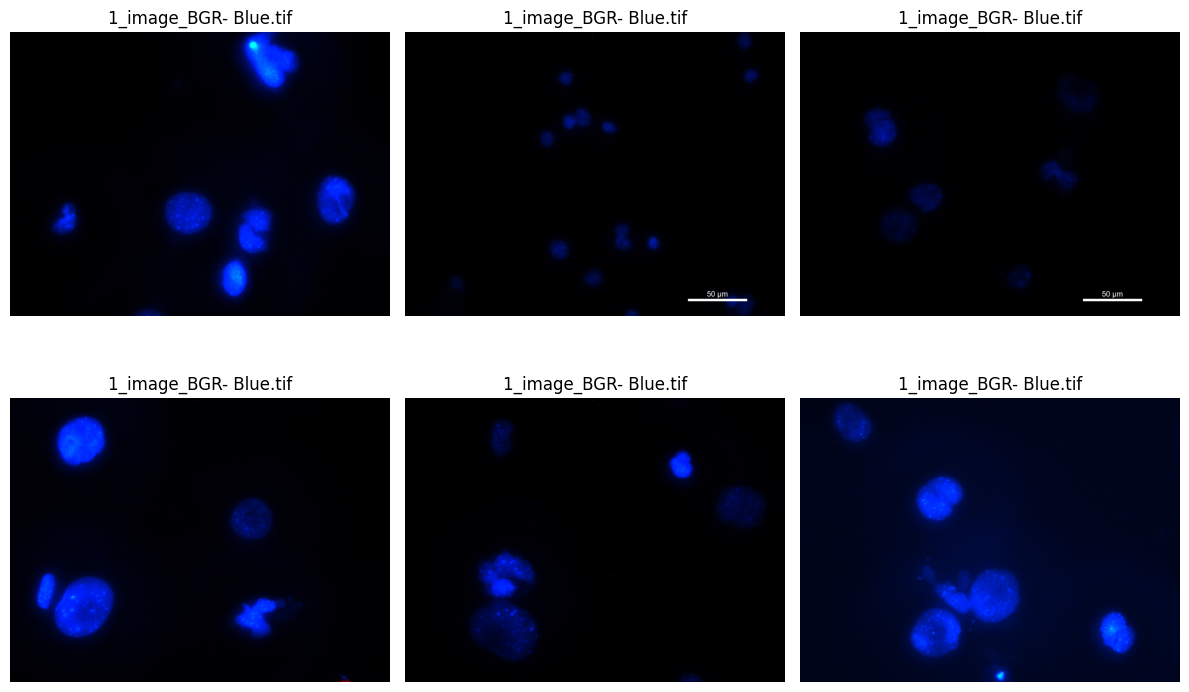

Overall intensity range: 0 - 255
Number of images: 33
Total pixels: 47773440


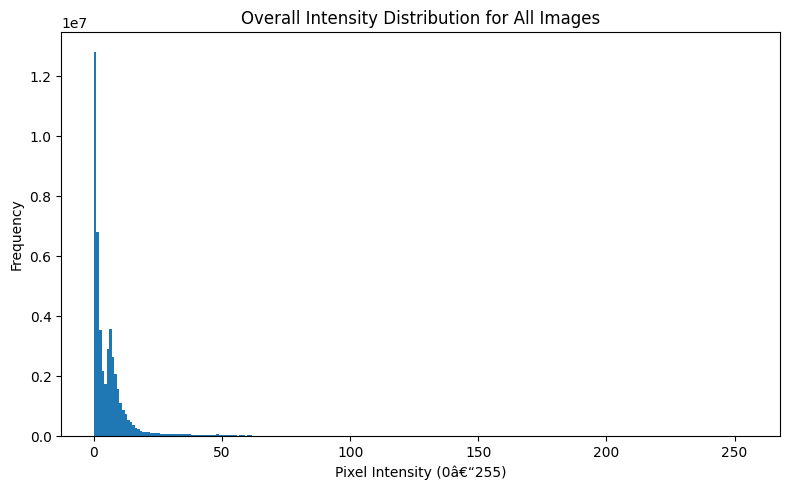

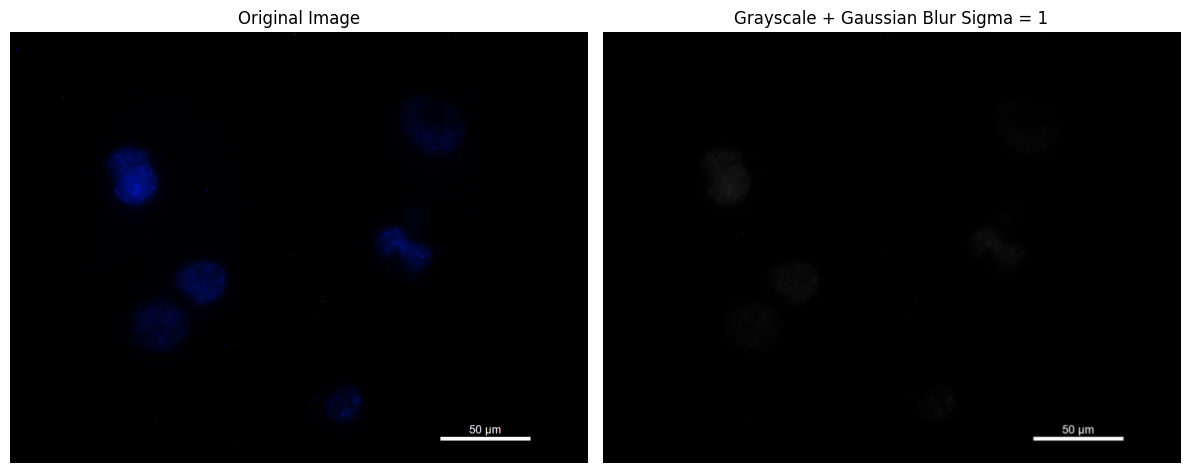

Detected Blobs (incl. Noise): 49

--- Blob Area Statistics (Pre-Filter) ---
Total Blobs: 49
Min Area: 1.0, Max Area: 14075.0, Average Area: 1260.02


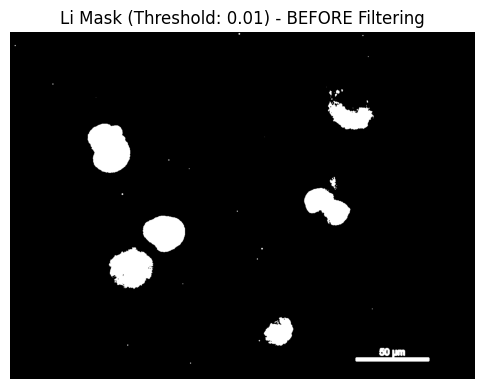

Average Area: 1260.02. Minimum Size Filter applied: 1260 pixels

--- Final Filtered Results ---
Objects Remaining (Cells): 7
Total Area Remaining: 60242.0


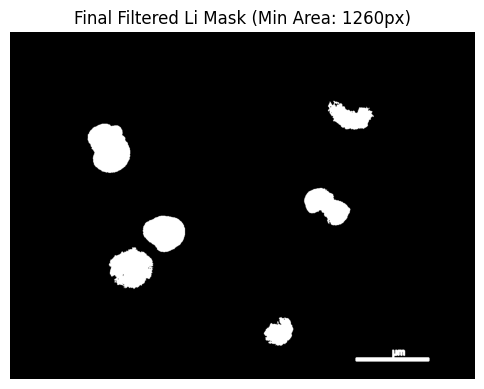

ImportError: cannot import name 'analize_cell_sizes' from 'ipynb.fs.full.cell_detection' (unknown location)

In [7]:
# Cell 2: Foci Detection and ROC Preparation

from ipynb.fs.full.cell_detection import analize_cell_sizes
from skimage.measure import label, regionprops, regionprops_table
from skimage.morphology import remove_small_objects

# Globale Parameter für die Detektion
MIN_DISTANCE = 10  # Mindestabstand zwischen Foci (Pixel)

# HINWEIS: Jetzt verwenden wir einen festen, globalen Schwellenwert T auf den normierten Daten!

def detect_foci_for_roc(img_norm, threshold_abs, min_distance):
    """Führt die Peak Detection auf den normierten Daten durch."""

    # Verwende Peak Detection, um genaue Koordinaten zu erhalten
    coords = feature.peak_local_max(
        img_norm,
        min_distance=min_distance,
        threshold_abs=threshold_abs,
        exclude_border=False
    )

    # Erstelle eine binäre Maske MT (M_Threshold) aus den erkannten Peaks
    mask_mt = np.zeros_like(img_norm, dtype=bool)
    if len(coords) > 0:
        mask_mt[coords[:, 0], coords[:, 1]] = True

    # Optional: Morphologische Erweiterung der Peaks, falls Maske für Flächenanalyse benötigt wird
    # mask_mt = morphology.binary_dilation(mask_mt, selem=morphology.disk(1))

    return mask_mt, coords

# --- 1. Definition der Schwellenwerte T zur Iteration ---
# Da die Daten z-normiert sind, liegen die Werte oft zwischen -3 und +3.
# Wir testen positive Werte, da Foci positive Abweichungen vom Mittelwert sind.
threshold_values = np.arange(0.5, 4.0, 0.25)
roc_data = [] # Speichert (T, TPR, FPR)

# --- 2. HINWEIS: GROUND TRUTH MUSS HIER GELADEN WERDEN ---
# Für eine tatsächliche ROC-Analyse benötigen Sie eine manuelle Maske.
# Beispiel: manual_mask = io.imread("pfad/zur/manual_mask.png") > 0.5

# Da die Ground Truth (GT) nicht vorhanden ist, simulieren wir den Prozess
print("\n--- Prozessstart: ROC-Voriteration (Ground Truth fehlt) ---")
print("Bitte manuell GT-Maske erstellen (manual_mask) und hier laden!")

# SIMULATION DER DETEKTION FÜR VERSCHIEDENE THRESHOLDS
for T in threshold_values:
    mask_mt, coords = detect_foci_for_roc(img_red_norm, T, MIN_DISTANCE)

    # Hier müsste normalerweise der Vergleich mit der GT stattfinden:
    # 1. Zähler berechnen (TP, FP, FN, TN)
    # 2. TPR und FPR berechnen
    # 3. roc_data.append((T, TPR, FPR))

    # Für die Demonstration: Ausgabe der Anzahl der erkannten Foci pro T
    print(f"Threshold T={T:.2f}: {len(coords)} Foci erkannt.")

    # Visualisierung des Schwellenwerts (optional)
    if T == 2.0:
        plt.figure(figsize=(6, 6))
        plt.imshow(img_red_norm, cmap='coolwarm')
        plt.plot(coords[:, 1], coords[:, 0], 'wo', label=f'Foci (T={T:.2f})',
                 markersize=5, markeredgewidth=1)
        plt.title("Detektion auf Normiertem Bild (T=2.0)")
        plt.legend()
        plt.axis('off')
        plt.show()

# --- 3. Abschließender Schritt ---
# Wenn Sie die ROC-Daten haben, plotten Sie diese:
# plt.figure(figsize=(6, 6))
# plt.plot([d[2] for d in roc_data], [d[1] for d in roc_data], marker='o') # FPR vs TPR
# plt.xlabel('False Positive Rate (FPR)')
# plt.ylabel('True Positive Rate (TPR)')
# plt.title('ROC Curve')
# plt.show()

## Count Cells in Image and annotate

In [ ]:
import cv2
from skimage import io, measure


intensity_image = red_channel
#intensity_image = gray


'''if image.ndim == 3:
    intensity_image = image[:, :, 0] # Red channel
else:
    intensity_image = image'''

# 2. Find Cells (Segmentation)
cell_mask = intensity_image > 0
labeled_cells = measure.label(cell_mask)
regions = measure.regionprops(labeled_cells)

print(f"Found {len(regions)} cells.")

# Preparation for Annotation
# Convert the single-channel intensity image to a 3-channel image for drawing to allow colored annotation
output_image = cv2.cvtColor(intensity_image, cv2.COLOR_GRAY2BGR)

#Annotation Loop
for i, region in enumerate(regions):
    # Skip tiny noise
    if region.area < 50:
        continue

    # 1. Get coordinates of the cell
    minr, minc, maxr, maxc = region.bbox

    # Draw Bounding Box
    # The order is (column, row) for the top-left and bottom-right corners
    cv2.rectangle(output_image, (minc, minr), (maxc, maxr), (0, 255, 0), 1)

    # Add Label (Cell ID - White)
    label_text = str(region.label)
    # Label is placed slightly inside the top-left corner
    cv2.putText(output_image, label_text, (minc + 5, minr + 20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

#Display Result
plt.figure(figsize=(8, 8))
# OpenCV uses BGR internally, so we convert it to RGB for Matplotlib
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.title(f"Detected Cells with Bounding Boxes")
plt.axis("off")
plt.show()


In [ ]:
import numpy as np
import cv2
from skimage import io, measure, feature # Added feature for peak detection
import matplotlib.pyplot as plt


# 2. Find Cells (Segmentation)
cell_mask = intensity_image > 0
labeled_cells = measure.label(cell_mask)
regions = measure.regionprops(labeled_cells, intensity_image=intensity_image) # Pass intensity_image for region properties

print(f"Found {len(regions)} cells.")

# --- Preparation for Annotation & Dataframe ---
output_image = cv2.cvtColor(intensity_image, cv2.COLOR_GRAY2BGR)
foci_records = []
peak_id_counter = 1

# --- Annotation and Foci Detection Loop ---
for region in regions:
    # Skip tiny noise
    if region.area < 50:
        continue

    # 1. Get coordinates of the cell bounding box (row min/max, col min/max)
    minr, minc, maxr, maxc = region.bbox

    # Draw Cell Bounding Box (Green)
    cv2.rectangle(output_image, (minc, minr), (maxc, maxr), (0, 255, 0), 1)

    # Add Cell Label
    cv2.putText(output_image, str(region.label), (minc + 5, minr + 20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    # 2. Extract the local intensity data for the current cell region
    # We use the bounding box to crop the original intensity map
    cropped_intensity = intensity_image[minr:maxr, minc:maxc]

    # 3. Detect Peaks (Foci) within the cropped region
    # Set a detection threshold relative to the overall max intensity of the image (or customize)
    peak_coords_local = feature.peak_local_max(
        cropped_intensity,
        min_distance=5,  # Minimum pixel distance between peaks
        threshold_abs=np.percentile(intensity_image, 99) * 0.4 # Tune this threshold
    )

    # 4. Annotate and Record Foci
    for local_r, local_c in peak_coords_local:
        # Convert local coordinates back to global image coordinates
        global_r = minr + local_r
        global_c = minc + local_c

        #Annotation: Foci Center
        cv2.circle(output_image, (global_c, global_r), 1, (0, 255, 0), -1)

        #Annotation: Circle around Foci
        # The radius of the circle is an estimate (e.g., min_distance/2)
        #radius = 5 # Use a fixed radius for visualization
        cv2.circle(output_image, (global_c, global_r), radius, (0, 255, 0), 1)

        # --- Data Collection ---
        foci_records.append({
            "cell_id": region.label,
            "peak_id": peak_id_counter,
            "global_x": global_c,
            "global_y": global_r,
            "intensity": intensity_image[global_r, global_c],
            "cell_area": region.area
        })
        peak_id_counter += 1

# Convert Records to DataFrame
df = pd.DataFrame(foci_records)
csv_path = "output/cell_foci_analysis.csv"
df.to_csv(csv_path, index=False)

# --- Display Result ---
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.title(f"Detected Cells and Foci (Total Foci: {len(foci_records)})")
plt.axis("off")
plt.show()

print(f"\nFoci data saved to {csv_path}")

In [ ]:
import numpy as np
import cv2
import pandas as pd
from skimage import io, measure, feature
import matplotlib.pyplot as plt
from skimage.draw import disk

#Find Cells
cell_mask = intensity_image > 0
labeled_cells = measure.label(cell_mask)
regions = measure.regionprops(labeled_cells, intensity_image=intensity_image)

output_image = cv2.cvtColor(intensity_image, cv2.COLOR_GRAY2BGR)
foci_records = []
peak_id_counter = 1

#Annotation and Foci Detection Loop
for region in regions:
    #Skip tiny noise
    if region.area < 50:
        continue

    #Get cell bounding box (row min/max, col min/max)
    minr, minc, maxr, maxc = region.bbox

    #Draw Cell Bounding Box (Green)
    cv2.rectangle(output_image, (minc, minr), (maxc, maxr), (0, 255, 0), 1)

    #Add Cell Label
    cv2.putText(output_image, str(region.label), (minc + 5, minr + 20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    #Extract the local intensity data for the current cell region
    cropped_intensity = intensity_image[minr:maxr, minc:maxc]

    #Blob Detection --- Laplacian of Gaussian
    #Find bright blobs and estimate their size (sigma)
    #The returned array is [row, column, sigma]
    blobs_log = feature.blob_log(
        cropped_intensity,
        min_sigma=2,    #Smallest expected focus size (size in pixels)
        max_sigma=5,   #Largest expected focus size
        num_sigma=10,
        threshold=0.05   #Lower threshold detects fainter foci; between 0 and 1
    )

    #Convert sigma to radius (radius = sigma * sqrt(2))
    blobs_log[:, 2] = blobs_log[:, 2] * np.sqrt(2)

    #Annotate and Record Foci
    for local_r, local_c, radius in blobs_log:
        local_r, local_c = int(local_r), int(local_c)

        # Convert local coordinates back to global image coordinates
        global_r = minr + local_r
        global_c = minc + local_c

        # Check if the blob center is actually inside the segmented cell mask
        if labeled_cells[global_r, global_c] != region.label:
            continue

        #Annotation: Center
        cv2.circle(output_image, (global_c, global_r), 1, (0, 255, 0), -1)

        #Annotation: estimated radius
        cv2.circle(output_image, (global_c, global_r), int(radius), (0, 255, 0), 1)

        #Use the calculated radius to define the focus area
        focus_radius = int(round(radius))

        #Create coordinates for the focus disk centered at (global_r, global_c)
        rr, cc = disk((global_r, global_c), focus_radius, shape=intensity_image.shape)

        #Extract the intensities from the image that fall within the disk coordinates
        focus_intensities = intensity_image[rr, cc]

        #Calculate the mean intensity over the focus area
        intensity_mean = np.mean(focus_intensities)

        #Data Collection
        foci_records.append({
            "cell_id": region.label,
            "peak_id": peak_id_counter,
            "global_x": global_c,
            "global_y": global_r,
            "intensity_mean": round(intensity_mean, 2),
            "intensity_peak": intensity_image[global_r, global_c],
            "foci_radius_pixels": round(radius, 2),
            "foci_area_approx": round(np.pi * (radius**2), 2),
            "cell_area": round(region.area),
            "image_id":""  #Empty for now; wo only analyze one image ToDo: find way to extract name from folder for each image
        })
        peak_id_counter += 1

#Convert Records to DataFrame
df = pd.DataFrame(foci_records)
csv_path = "output/cell_foci_log_analysis.csv"
df.to_csv(csv_path, index=False)

print(f"Total Cells: {len(regions)}")
print(f"Total Foci: {len(foci_records)}")
print(df.head(2))

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.title(f"Detected Cells and Blobs")
plt.axis("off")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, measure, feature, color

def analyze_cells_relative_threshold(image_path, relative_threshold, min_distance, max_cells=10):

    # --- 1. Load & Prepare Images ---
    # Load original
    image = io.imread(image_path)

    # Handle RGB vs Grayscale
    if image.ndim == 2:
        img_rgb = color.gray2rgb(image)
        img_red = image
    elif image.shape[2] == 4: # RGBA
        img_rgb = image[:, :, :3]
        img_red = image[:, :, 0]
    else: # RGB
        img_rgb = image
        img_red = image[:, :, 0]

    # Pre-calculate Grayscale for comparison
    img_gray = color.rgb2gray(img_rgb)
    # Scale grayscale to 0-255 if needed for fair histogram comparison
    if img_gray.max() <= 1.0 and img_red.max() > 1.0:
        img_gray = img_gray * 255

    # --- 2. Find Cells ---
    # Threshold > 0 to find cell shapes
    cell_mask = img_red > 0
    labeled_cells = measure.label(cell_mask)
    regions = measure.regionprops(labeled_cells, intensity_image=img_red)

    print(f"Found {len(regions)} cells. Showing first {max_cells}...")

    # --- 3. Process Individual Cells ---
    for i, region in enumerate(regions):
        if i >= max_cells:
            break

        if region.area < 50: # Skip noise
            continue

        # --- A. Extract Data for THIS Cell ---
        minr, minc, maxr, maxc = region.bbox

        # Crop 1: Red Channel (The Signal)
        crop_red = img_red[minr:maxr, minc:maxc].copy()
        crop_red[~region.image] = 0 # Zero out background

        # Crop 2: Grayscale (The Comparison)
        crop_gray = img_gray[minr:maxr, minc:maxc].copy()
        crop_gray[~region.image] = 0

        # --- B. Find Peaks (Relative Threshold) ---
        # 1. Find max intensity in THIS cell
        cell_max = crop_red.max()

        # 2. Calculate the specific cutoff for THIS cell
        abs_threshold = cell_max * relative_threshold

        if abs_threshold <= 0:
            continue

        # 3. Detect
        local_peaks = feature.peak_local_max(
            crop_red,
            min_distance=min_distance,
            threshold_abs=abs_threshold, # We calculated this dynamically above
            exclude_border=False
        )

        # --- C. Visualization ---
        fig, ax = plt.subplots(1, 3, figsize=(18, 5))

        # Plot 1: The Cell with Peaks
        ax[0].imshow(crop_red, cmap='gray')
        ax[0].set_title(f"Cell #{i+1} (Max: {cell_max})")
        # Plot peaks
        ax[0].plot(local_peaks[:, 1], local_peaks[:, 0], 'rx', markersize=8, markeredgewidth=2)

        # Plot 2: Red Histogram
        ax[1].hist(crop_red[region.image], bins=50, color='red', alpha=0.7)
        ax[1].axvline(abs_threshold, color='blue', linestyle='--', linewidth=2, label=f'Thresh ({relative_threshold*100:.0f}%)')
        ax[1].set_title("Red Channel Histogram")
        ax[1].legend()

        # Plot 3: Grayscale Histogram
        ax[2].hist(crop_gray[region.image], bins=50, color='gray', alpha=0.7)
        ax[2].set_title("Grayscale Histogram")

        plt.tight_layout()
        plt.show()


# Change 'relative_threshold' to tune sensitivity (0.6 = 60% of max brightness)
analyze_cells_relative_threshold(
    "output/masks/Li_masked.png",
    relative_threshold=0.55,
    min_distance=12
)

In [ ]:
import os

def analyze_cells_relative_threshold(relative_threshold, min_distance, max_cells=10):

    #use image that is not gray
    img_red = red_channel

    # --- 2. Find Cells ---
    # Threshold > 0 to find cell shapes
    cell_mask = img_red > 0
    labeled_cells = measure.label(cell_mask)
    regions = measure.regionprops(labeled_cells, intensity_image=img_red)

    print(f"Found Cells: {len(regions)}")

    # --- 3. Process Individual Cells ---
    for i, region in enumerate(regions):
        if i >= max_cells:
            break

        if region.area < 50: # Skip noise
            continue

        # --- A. Extract Data for THIS Cell ---
        minr, minc, maxr, maxc = region.bbox

        # Crop Red Channel (The Signal)
        crop_red = img_red[minr:maxr, minc:maxc].copy()
        crop_red[~region.image] = 0 # Zero out background

        # Note: Grayscale related code removed from here.

        # --- B. Find Peaks (Relative Threshold) ---
        # 1. Find max intensity in THIS cell
        cell_max = crop_red.max()

        # 2. Calculate the specific cutoff for THIS cell
        abs_threshold = cell_max * relative_threshold

        if abs_threshold <= 0:
            continue

        # 3. Detect
        local_peaks = feature.peak_local_max(
            crop_red,
            min_distance=min_distance,
            threshold_abs=abs_threshold, # Dynamic threshold
            exclude_border=False
        )

        # --- C. Visualization ---
        # Reduced subplots from 3 to 2
        fig, ax = plt.subplots(1, 2, figsize=(12, 5))

        # Plot 1: The Cell with Peaks
        ax[0].imshow(crop_red, cmap='Reds') # Use 'Reds' for color consistency
        ax[0].set_title(f"Cell #{i+1} (Max: {cell_max}, Peaks: {len(local_peaks)})")
        # Plot peaks
        ax[0].plot(local_peaks[:, 1], local_peaks[:, 0], 'wo',
                   markerfacecolor='none', markeredgecolor='white',
                   markersize=8, markeredgewidth=1)

        # Plot 2: Red Histogram (Now uses the second subplot slot)
        ax[1].hist(crop_red[region.image], bins=50, color='red', alpha=0.7)
        ax[1].axvline(abs_threshold, color='blue', linestyle='--', linewidth=2,
                      label=f'Threshold ({relative_threshold*100:.0f}% of max)')
        ax[1].set_title("Red Channel Histogram")
        ax[1].set_xlabel("Intensity")
        ax[1].set_ylabel("Frequency")
        ax[1].legend()

        # Removed Plot 3 (Grayscale Histogram)

        plt.tight_layout()
        plt.show()


# Change 'relative_threshold' to tune sensitivity (0.55 = 55% of cell's max brightness)
analyze_cells_relative_threshold(
    relative_threshold=0.50,
    min_distance=10
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from skimage import io, measure, feature
from skimage.draw import disk
import cv2 # Required for drawing utilities



def analyze_cells_relative_threshold(relative_threshold, min_distance, max_cells=10):

    # Use image that is not gray

    img_red = red_channel

    # --- 1. Initialize Full Annotation Canvas ---
    # Convert single-channel red data to a 3-channel image for colored annotations (BGR order)
    zeros = np.zeros_like(img_red)
    full_output_canvas = cv2.merge([zeros, zeros, img_red]) # Creates a red-colored image

    # --- 2. Find Cells ---
    cell_mask = img_red > 0
    labeled_cells = measure.label(cell_mask)
    # Using img_red for regionprops to get intensity data
    regions = measure.regionprops(labeled_cells, intensity_image=img_red)

    print(f"Found Cells: {len(regions)}")

    foci_records = []
    peak_id_counter = 1
    image_filename = os.path.basename(image_path)
    image_id_value = os.path.splitext(image_filename)[0]


    # --- 3. Process Individual Cells ---
    for i, region in enumerate(regions):
        if i >= max_cells:
            break

        if region.area < 50: # Skip noise
            continue

        # --- A. Extract Data for THIS Cell ---
        minr, minc, maxr, maxc = region.bbox

        # Crop Red Channel (The Signal)
        crop_red = img_red[minr:maxr, minc:maxc].copy()
        crop_red[~region.image] = 0 # Zero out background

        # --- Draw Annotations on FULL IMAGE CANVAS (NEW) ---
        # 1. Draw Bounding Box (Green)
        cv2.rectangle(full_output_canvas, (minc, minr), (maxc, maxr), (0, 255, 0), 1)
        # 2. Add Cell Label (White)
        cv2.putText(full_output_canvas, str(region.label), (minc + 5, minr + 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        # ----------------------------------------------------


        # --- B. Find Peaks (Relative Threshold - using peak_local_max) ---
        cell_max = crop_red.max()
        abs_threshold = cell_max * relative_threshold

        if abs_threshold <= 0:
            continue

        local_peaks = feature.peak_local_max(
            crop_red,
            min_distance=min_distance,
            threshold_abs=abs_threshold,
            exclude_border=False
        )

        # --- C. Data Collection & Foci Annotation on FULL IMAGE CANVAS ---
        for local_r, local_c in local_peaks:

            # Convert local coordinates back to global image coordinates
            global_r = int(minr + local_r)
            global_c = int(minc + local_c)

            # --- Foci Annotation on FULL IMAGE (NEW) ---
            # Draw tiny white dot at the center of the peak
            cv2.circle(full_output_canvas, (global_c, global_r), 2, (255, 255, 255), -1)

            # --- Data Collection (Requires integration with former LoG code for size metrics) ---
            # NOTE: Since you removed LoG, size metrics (radius/area) are undefined here.
            # We'll use placeholder or only include defined metrics.

            foci_records.append({
                "cell_id": region.label,
                "peak_id": peak_id_counter,
                "global_x": global_c,
                "global_y": global_r,
                "intensity_peak": img_red[global_r, global_c],
                "foci_radius_pixels": 0.0, # Placeholder/Undefined without Blob LoG
                "cell_area": round(region.area),
                "image_id": image_id_value
            })
            peak_id_counter += 1

        # --- D. Visualization of Single Cell and Histogram ---
        # (This remains the same as your original request for side-by-side view)
        fig, ax = plt.subplots(1, 2, figsize=(12, 5))
        # Plot 1: The Cell with Peaks
        ax[0].imshow(crop_red, cmap='Reds')
        ax[0].set_title(f"Cell #{i+1} (Max: {cell_max}, Peaks: {len(local_peaks)})")
        # Plot peaks
        ax[0].plot(local_peaks[:, 1], local_peaks[:, 0], 'wo',
                   markerfacecolor='none', markeredgecolor='white',
                   markersize=8, markeredgewidth=1)

        # Plot 2: Red Histogram
        ax[1].hist(crop_red[region.image], bins=50, color='red', alpha=0.7)
        ax[1].axvline(abs_threshold, color='blue', linestyle='--', linewidth=2,
                      label=f'Threshold ({relative_threshold*100:.0f}% of max)')
        ax[1].set_title("Red Channel Histogram")
        ax[1].set_xlabel("Intensity")
        ax[1].set_ylabel("Frequency")
        ax[1].legend()

        plt.tight_layout()
        plt.show()

    # --- FINAL DISPLAY OF FULL ANNOTATED IMAGE (NEW) ---
    plt.figure(figsize=(10, 10))
    # Convert BGR canvas to RGB for correct Matplotlib display
    plt.imshow(cv2.cvtColor(full_output_canvas, cv2.COLOR_BGR2RGB))
    plt.title("Full Image Annotation: All Cells and Detected Foci")
    plt.axis('off')
    plt.show()

    # --- CSV Saving ---
    df = pd.DataFrame(foci_records)
    csv_path = f"output/{image_id_value}_foci_analysis.csv"
    os.makedirs(os.path.dirname(csv_path) or '.', exist_ok=True)
    df.to_csv(csv_path, index=False)

    print(f"\n--- Analysis Complete ---")
    print(f"Total Foci Detected: {len(foci_records)}")
    print(f"Data saved to: {csv_path}")
    print("\nFirst 5 rows of the generated DataFrame:")
    print(df.head(5))


# --- EXECUTION ---
analyze_cells_relative_threshold(
    relative_threshold=0.53,
    min_distance=12
)